In [1]:
# Q-gen tutorial
# 122225 Yikai Mao

In [2]:
# reproducibility
# %env PYTHONHASHSEED=0

In [3]:
from helper_functions import show_circuit, run_ideal_simulation, sim_result_analysis

# 00 Deutsch-Jozsa Algorithm

```python
def deutsch_jozsa(n, options=[]):
    # n = number of qubits of the oracle
    # options = [oracle, print_oracle]
    # oracle = 'constant' (easy), 'balanced' (hard)
    # print_oracle = 'print', 'silent'
```

In [4]:
from Q_gen_query.deutsch_jozsa import deutsch_jozsa

In [5]:
dj_circuit = deutsch_jozsa(4, ['balanced', 'print'])

balanced oracle = 1110
                                   
q_0: ───────■──────────────────────
     ┌───┐  │       ┌───┐          
q_1: ┤ X ├──┼────■──┤ X ├──────────
     ├───┤  │    │  └───┘┌───┐     
q_2: ┤ X ├──┼────┼────■──┤ X ├─────
     ├───┤  │    │    │  └───┘┌───┐
q_3: ┤ X ├──┼────┼────┼────■──┤ X ├
     └───┘┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐└───┘
q_4: ─────┤ X ├┤ X ├┤ X ├┤ X ├─────
          └───┘└───┘└───┘└───┘     


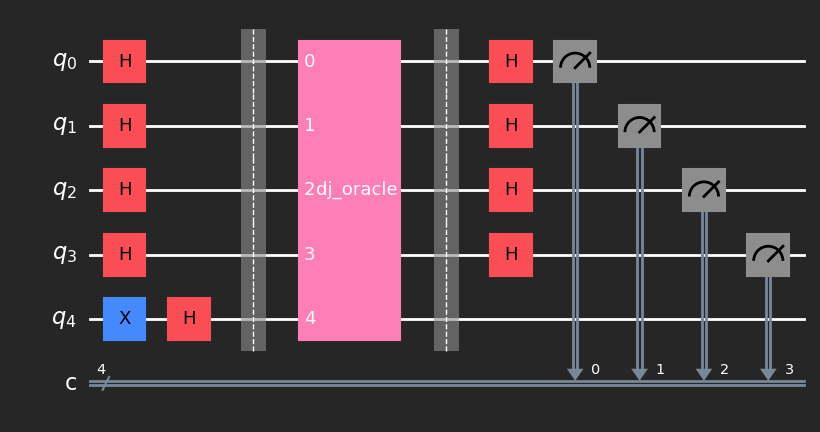

In [6]:
show_circuit(dj_circuit, 0)

# 01 Bernstein-Vazirani Algorithm

```python
def bernstein_vazirani(n, options=[]):
    # n = number of qubits of the oracle
    # options = [oracle, print_oracle]
    # oracle = 'random'
    # print_oracle = 'print', 'silent'
```

In [7]:
from Q_gen_query.bernstein_vazirani import bernstein_vazirani

In [8]:
bv_circuit = bernstein_vazirani(4, ['random', 'print'])

oracle = 1011


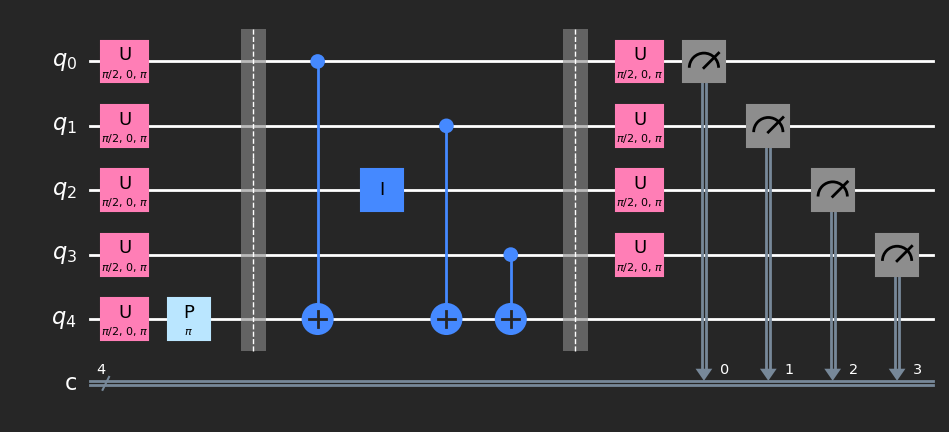

In [9]:
show_circuit(bv_circuit, 1)

# 02 Simon's Algorithm

```python
def simon(n, options=[]):
    # n = number of qubits of the oracle
    # options = [oracle, print_oracle]
    # oracle = 'random'
    # print_oracle = 'print', 'silent'

def simon_verify(b_str, counts):
    # verify the output of simon circuit
    # b_str = oracle binary string
    # counts = measurement counts
```

In [10]:
from Q_gen_query.simon import simon

In [11]:
simon_circuit = simon(4, ['random', 'print'])

oracle = 1100
                                   
q_0: ──■───────────────────────────
       │                           
q_1: ──┼────■──────────────────────
       │    │                      
q_2: ──┼────┼────■─────────■────■──
       │    │    │         │    │  
q_3: ──┼────┼────┼────■────┼────┼──
     ┌─┴─┐  │    │    │    │    │  
q_4: ┤ X ├──┼────┼────┼────┼────┼──
     └───┘┌─┴─┐  │    │    │    │  
q_5: ─────┤ X ├──┼────┼────┼────┼──
          └───┘┌─┴─┐  │  ┌─┴─┐  │  
q_6: ──────────┤ X ├──┼──┤ X ├──┼──
               └───┘┌─┴─┐└───┘┌─┴─┐
q_7: ───────────────┤ X ├─────┤ X ├
                    └───┘     └───┘


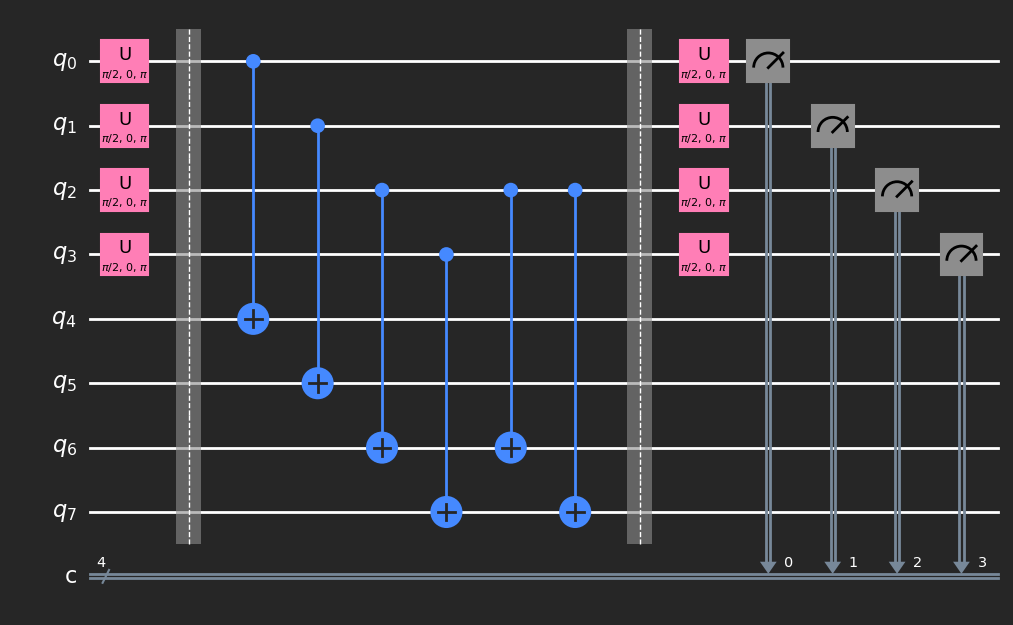

In [12]:
show_circuit(simon_circuit, 1)

In [13]:
from Q_gen_query.simon import simon_verify
from helper_functions import run_ideal_simulation, sim_result_analysis

In [14]:
simon_result = run_ideal_simulation(simon_circuit, 'CPU', 4096, 3, None, 'silent')
sim_time, raw_counts, sorted_counts, sorted_probs = sim_result_analysis(simon_result, 'silent', 'silent', 'silent', 'silent')

simon_verify('1100', raw_counts)

1100.0010 = 0 (mod 2)
1100.0000 = 0 (mod 2)
1100.1111 = 0 (mod 2)
1100.0001 = 0 (mod 2)
1100.1100 = 0 (mod 2)
1100.1101 = 0 (mod 2)
1100.1110 = 0 (mod 2)
1100.0011 = 0 (mod 2)
Passed


# 03 Quantum Fourier Transform Algorithm

```python
def qft(n, options=[]):
    # n = number of qubits
    # options = [initialize, inverse, measurement]
    # initialize = decimal number to be initialized in fourier basis, 0 = random, -1 = no initialization
    # inverse = 'normal', 'inverse', output inverse QFT
    # measurement = 'measure', 'no_measure', add measurement
```

In [15]:
from Q_gen_qft.qft import qft

In [16]:
qft_circuit = qft(4, [0, 'inverse', 'measure'])

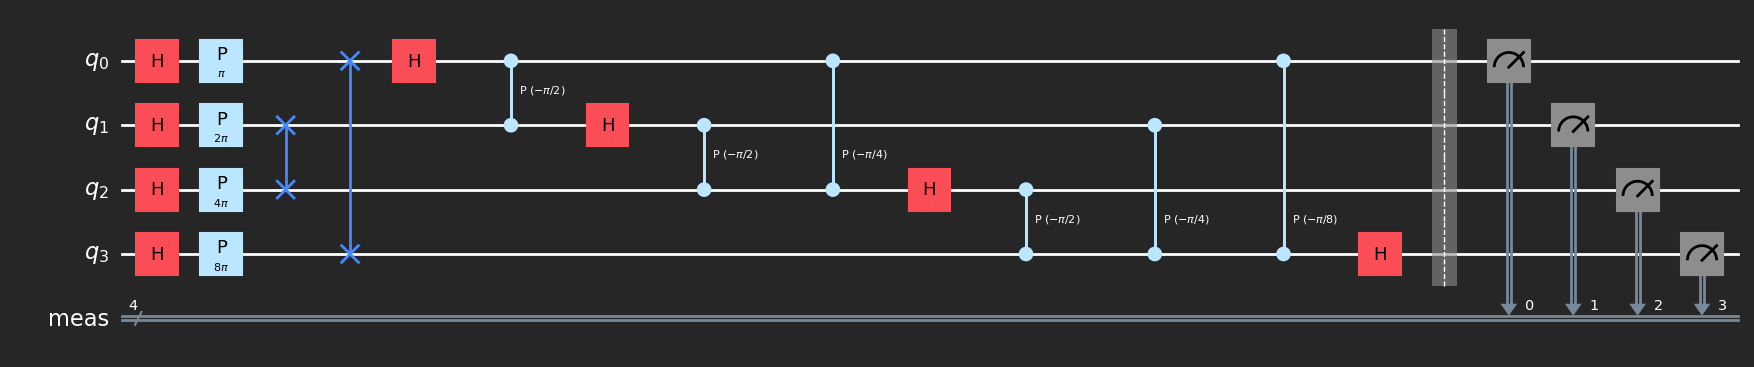

In [17]:
show_circuit(qft_circuit, 0)

# 04 Quantum Phase Estimation Algorithm

```python
def qpe(n, options=[]):
    # n = number of counting qubits
    # options = [phase_theta]
    # phase_theta = the decimal number to be initialized in fourier basis
```

In [18]:
from Q_gen_qft.qpe import qpe

In [19]:
qpe_qc = qpe(4, [1/8])

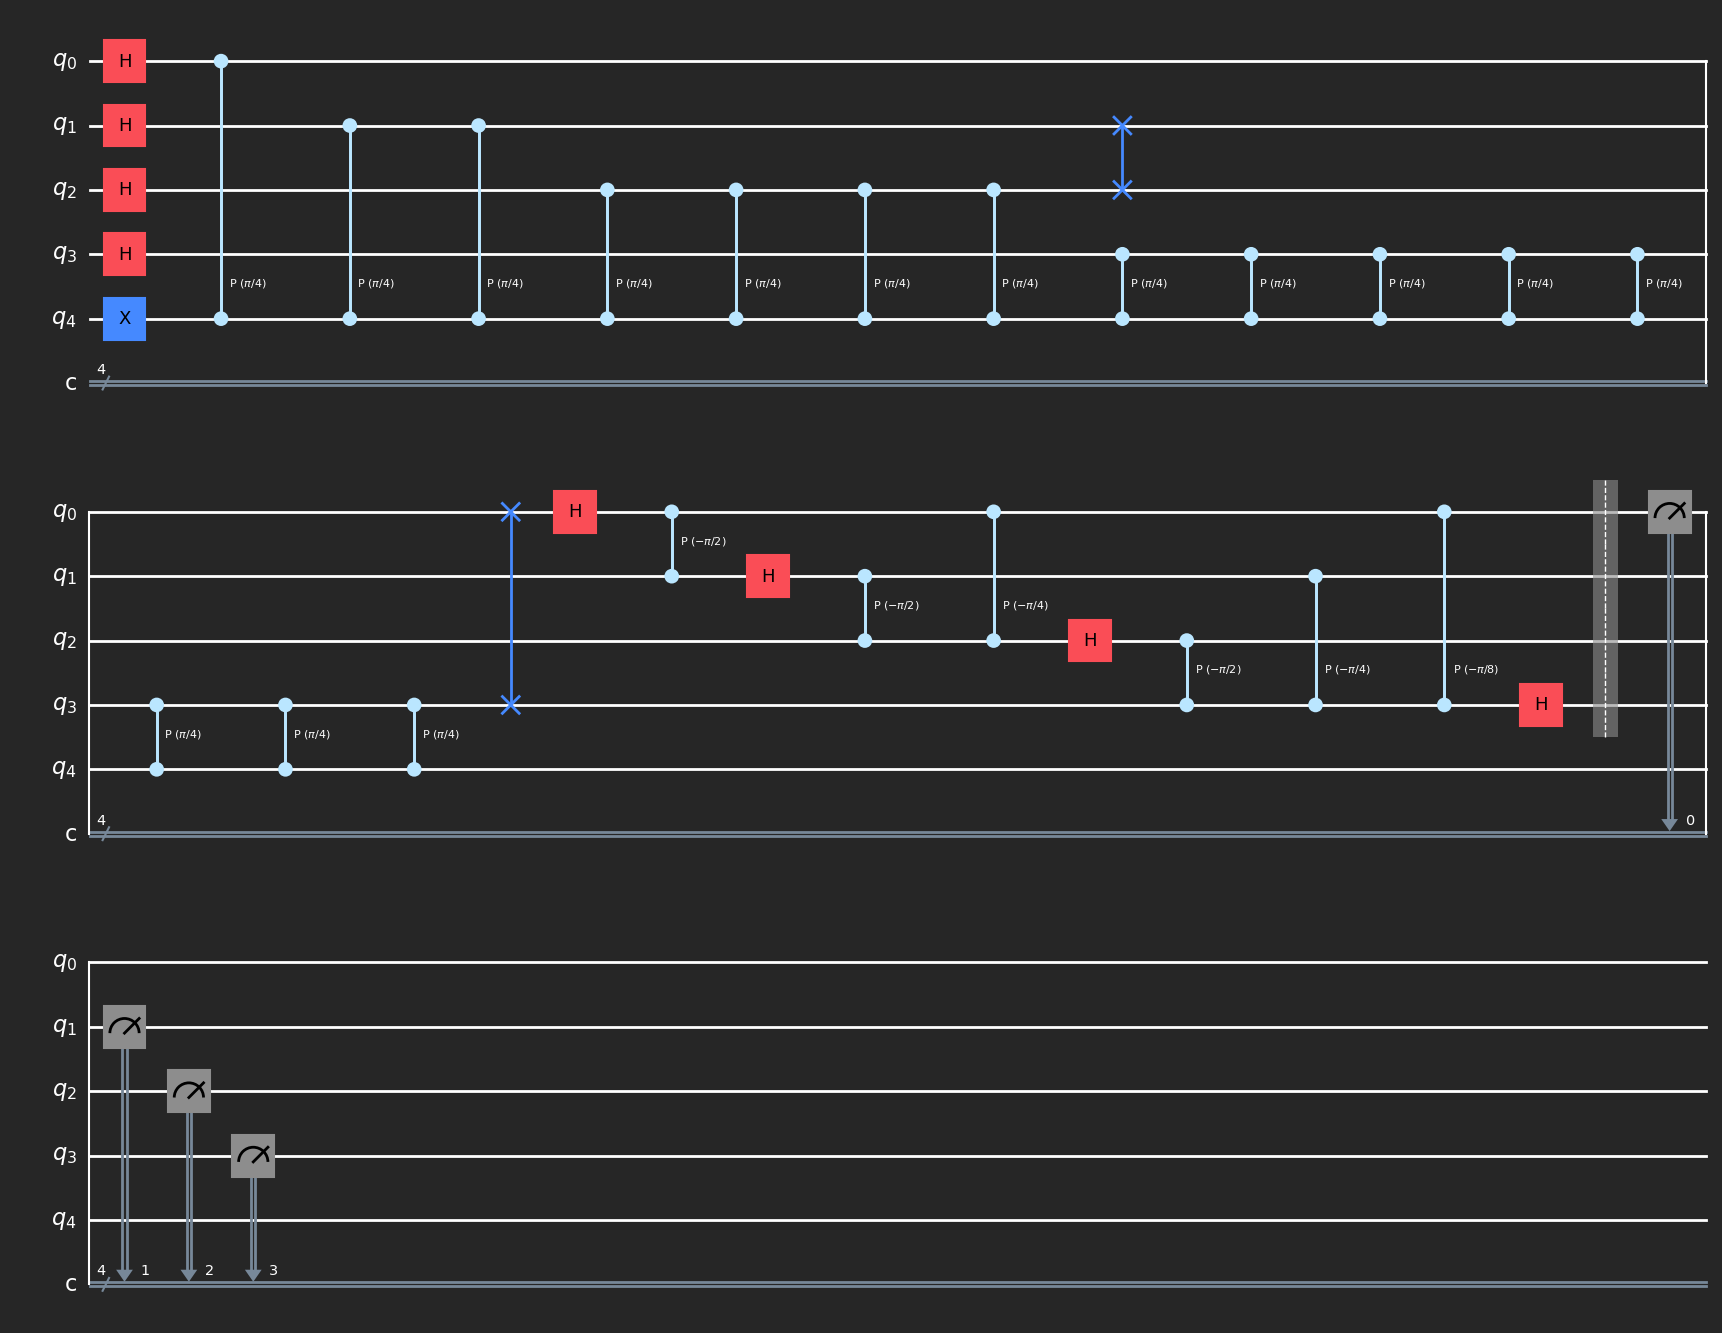

In [20]:
show_circuit(qpe_qc, 0)

# 05 Shor's Algorithm

```python
def shor(N, options=[]):
    # in Shor's algrithm, N is the number to be factored
    # options = [a]
    # a = 'random', use random a. 'min', use the smallest a
```

In [21]:
from Q_gen_qft.shor import shor

In [22]:
N = 15 #[15, 21, 35, 39, 51, 55, 57, 65, 69, 77, 85, 87, 91, 93, 95, 105, 111, 115, 119, 123]
random = 'random'

shor_circuit = shor(N, [random])

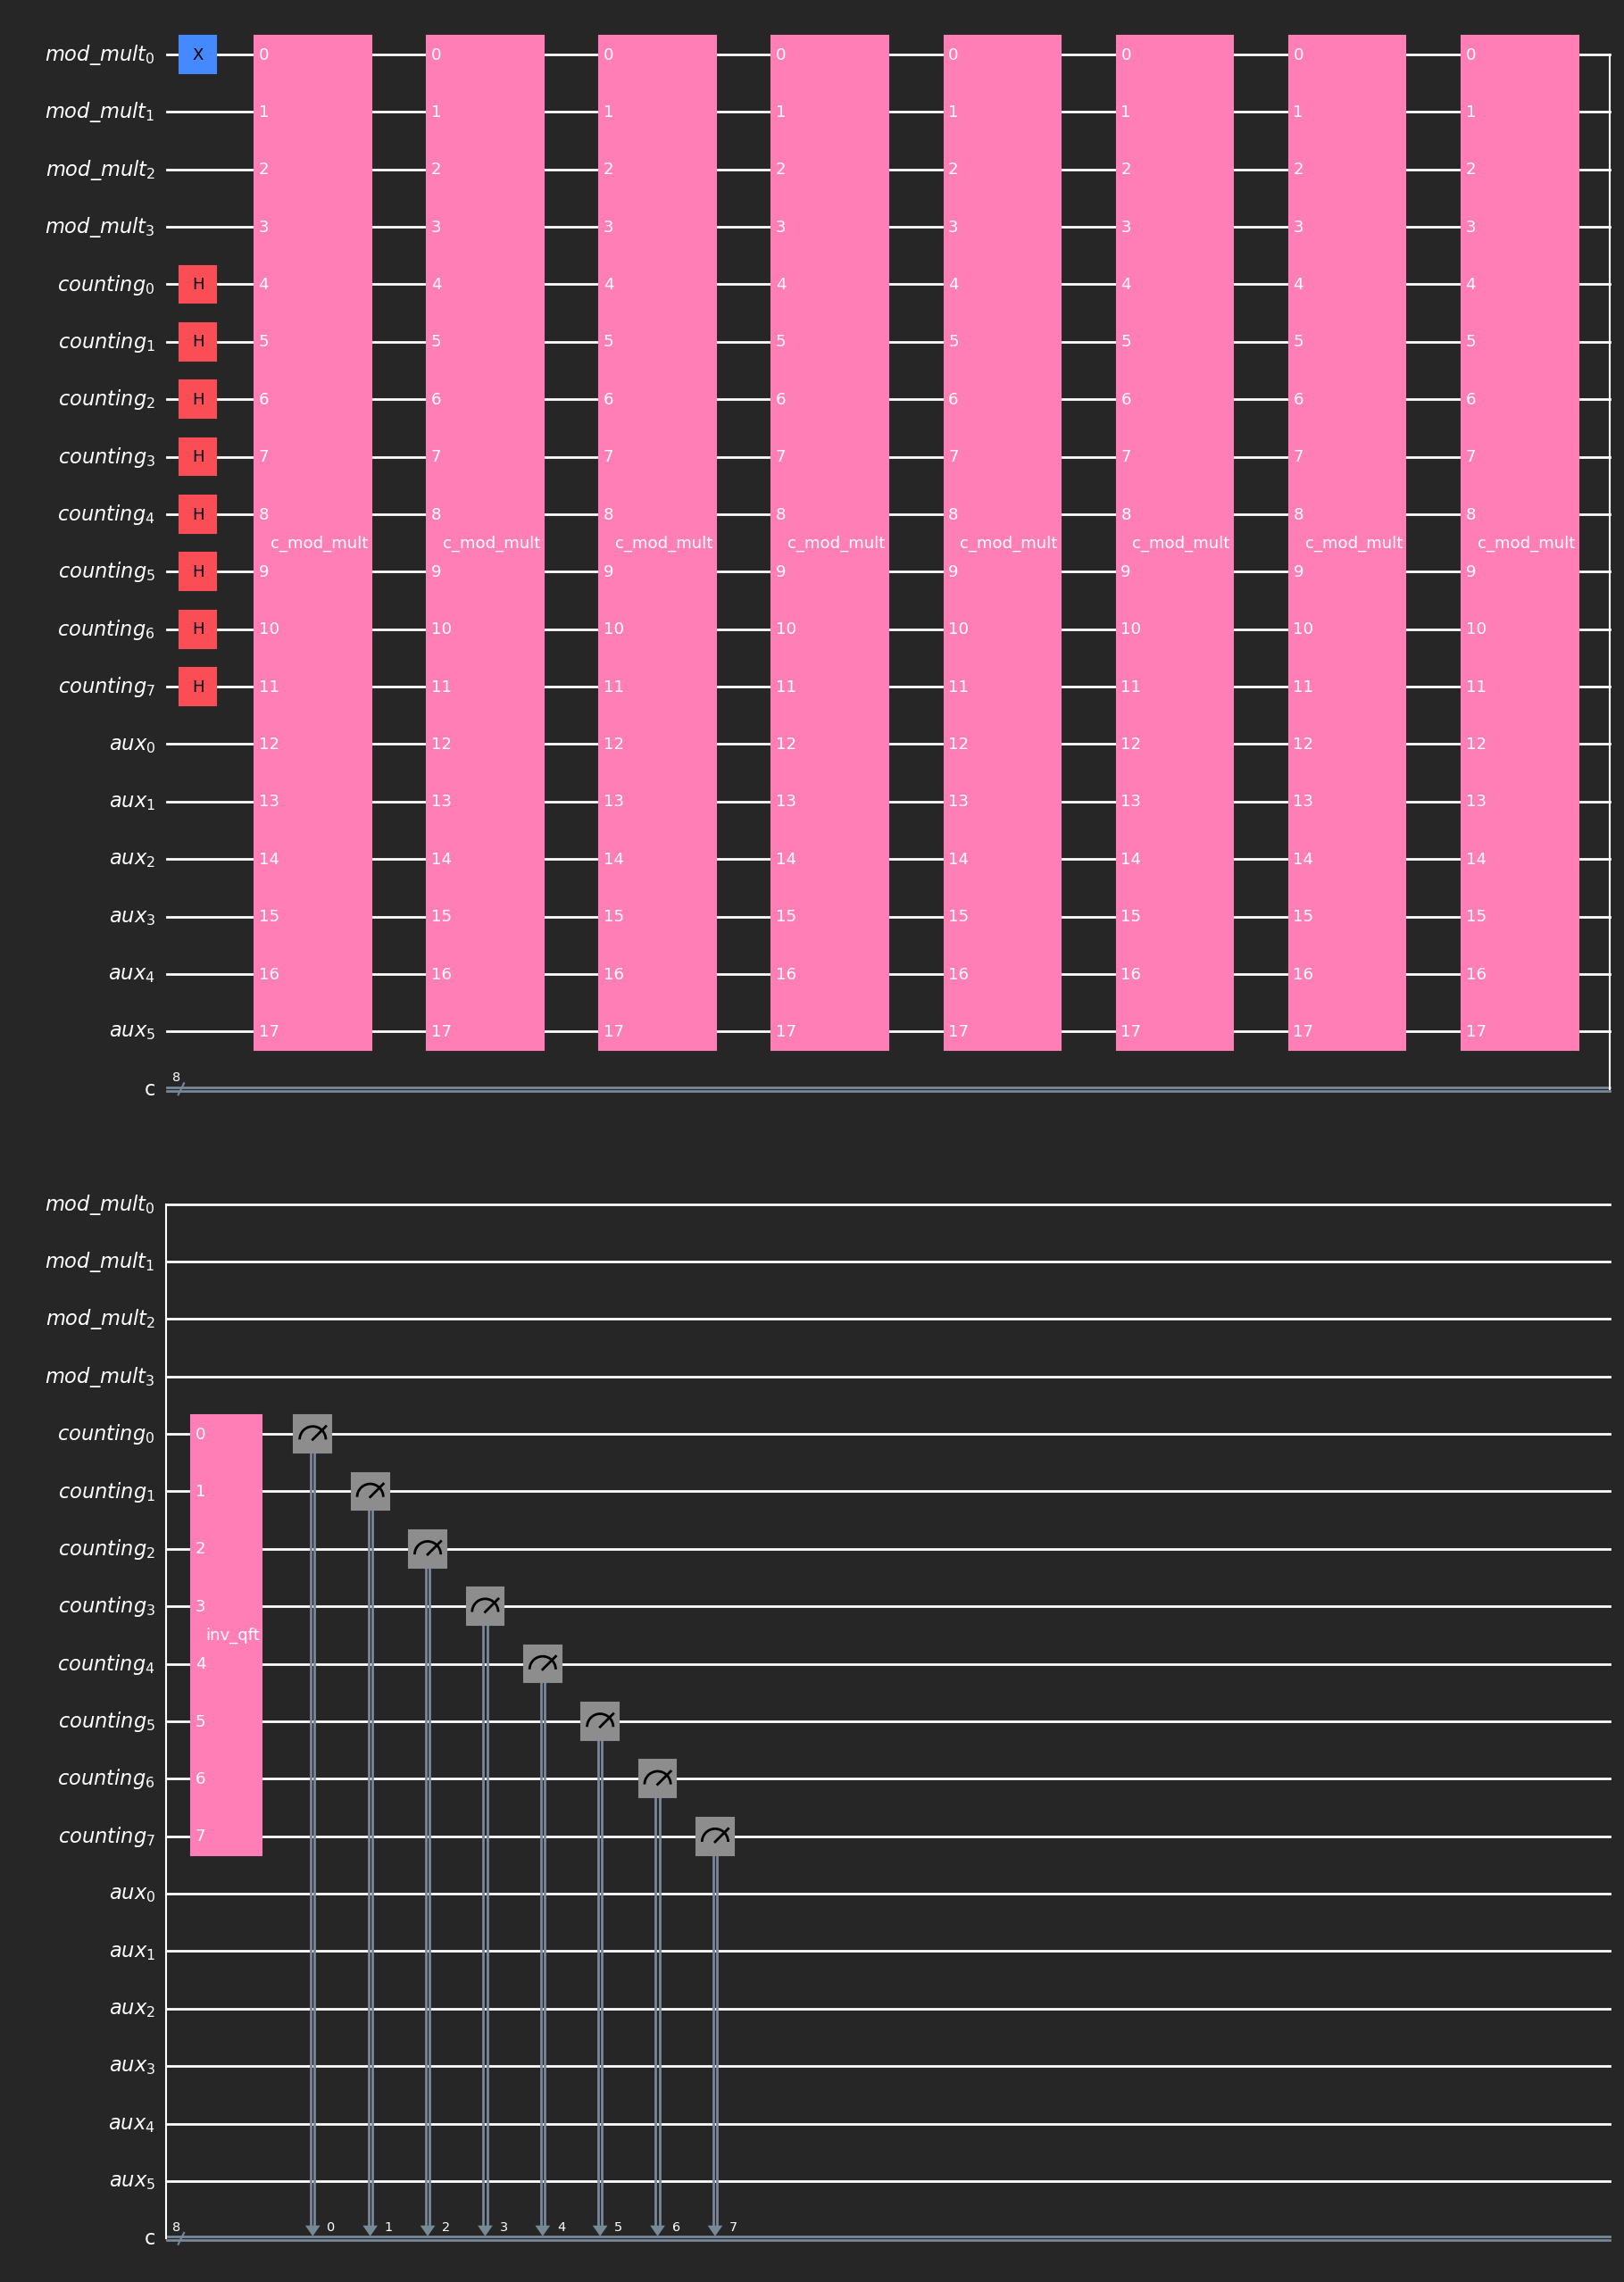

In [23]:
show_circuit(shor_circuit, 0)

# 06 Grover's Algorithm

```python
def grover(n, options=[]):
    # n = number of qubits of the grover oracle, n must >= 2
    # options = [print_solutions]
    # print_solutions = 'print', 'silent', show solutions and optimal iteration
    # optimal iteration will always be 1 here (due to nsolutions = 2**(n-2))
```

In [24]:
from Q_gen_search.grover import grover

In [25]:
grover_circuit = grover(4, ['print'])

solutions: ['0100', '1001', '1100', '1101']
total: 4
optimal iteration: 1


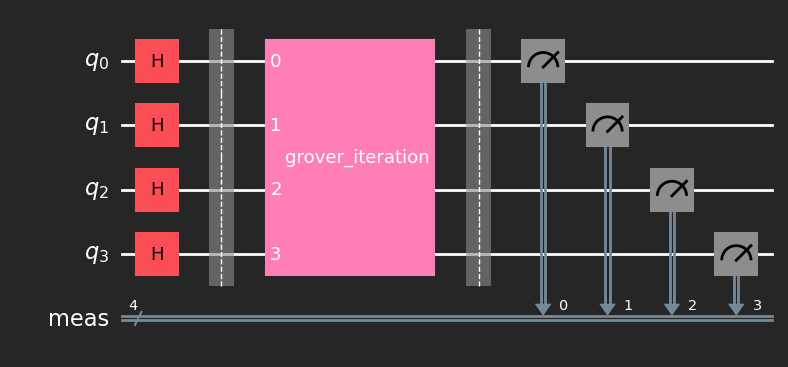

In [26]:
show_circuit(grover_circuit, 0)

# 07 Quantum Counting Algorithm

```python
def quantum_counting(n, options=[]):
    # Grover iteration circuit for oracle with M/N solutions
    # n = number of counting qubits, circuit has n+t qubits and t classical bits
    # options = [print_oracle]
    # print_oracle = 'print', 'silent'

def calculate_M(raw_counts, n):
    # For Processing Output of Quantum Counting
    # here n = the full qubit amount of the generated circuit
```

In [27]:
from Q_gen_search.quantum_counting import quantum_counting

In [28]:
counting_circuit = quantum_counting(4, ['print'])

counting qubits = 4
searching qubits = 4
num_solutions = 9
[1, -1, 1, -1, 1, -1, -1, 1, 1, 1, 1, -1, -1, -1, -1, -1]


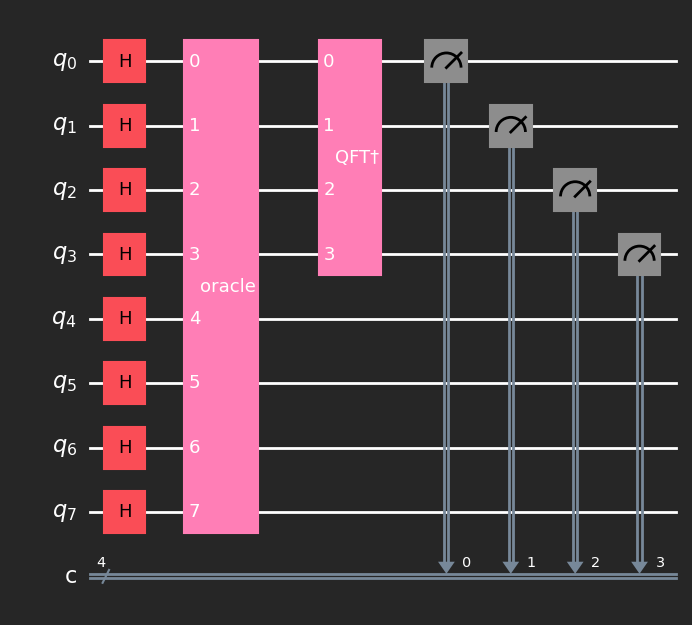

In [29]:
show_circuit(counting_circuit, 0)

In [30]:
from Q_gen_search.quantum_counting import calculate_M
from helper_functions import run_ideal_simulation, sim_result_analysis

---- START ----
simulator name = aer_simulator
max supported #qubits = 29
#qubits of circuit = 8
#clbits of circuit = 4
---- DONE ----
device = CPU
device time = 0.019610299
total time = 0.03481745719909668


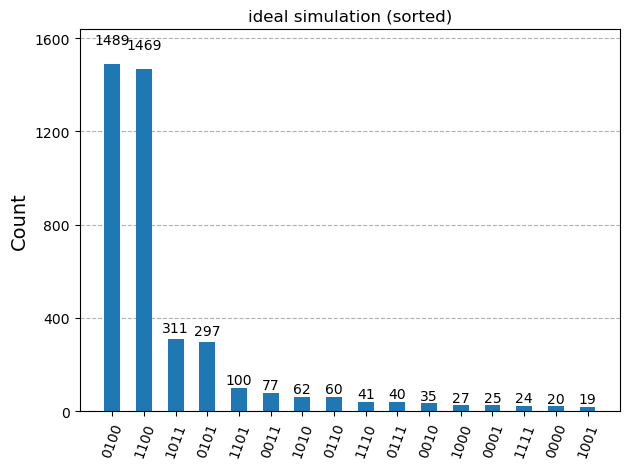

sorted counts:
{'0000': 20, '0001': 25, '0010': 35, '0011': 77, '0100': 1489, '0101': 297, '0110': 60, '0111': 40, '1000': 27, '1001': 19, '1010': 62, '1011': 311, '1100': 1469, '1101': 100, '1110': 41, '1111': 24}
sorted probabilities (%):
{'0000': 0.48828125, '0001': 0.6103515625, '0010': 0.8544921875, '0011': 1.8798828125, '0100': 36.3525390625, '0101': 7.2509765625, '0110': 1.46484375, '0111': 0.9765625, '1000': 0.6591796875, '1001': 0.4638671875, '1010': 1.513671875, '1011': 7.5927734375, '1100': 35.8642578125, '1101': 2.44140625, '1110': 1.0009765625, '1111': 0.5859375}
Register Output = 4
Theta = 1.57080
No. of Solutions = 8.0
Error < 2.12


In [31]:
counting_circuit_result = run_ideal_simulation(counting_circuit, 'CPU', 4096, 3, None, 'verbose')
sim_time, raw_counts, sorted_counts, sorted_probs = sim_result_analysis(counting_circuit_result, 'show_plot', 'show_counts', 'show_probs','verbose')

calculate_M(raw_counts, 4)

# 08 Quantum Walk Algorithm

```python
def quantum_walk(n, options=[]):
    # n = number of qubits of the coin, must >= 2
    # options = [print_solutions]
    # print_solutions = 'print', 'silent'
```

In [32]:
from Q_gen_search.quantum_walk import quantum_walk

In [33]:
quantum_walk_circuit = quantum_walk(2, ['print'])

solutions: ['0110']


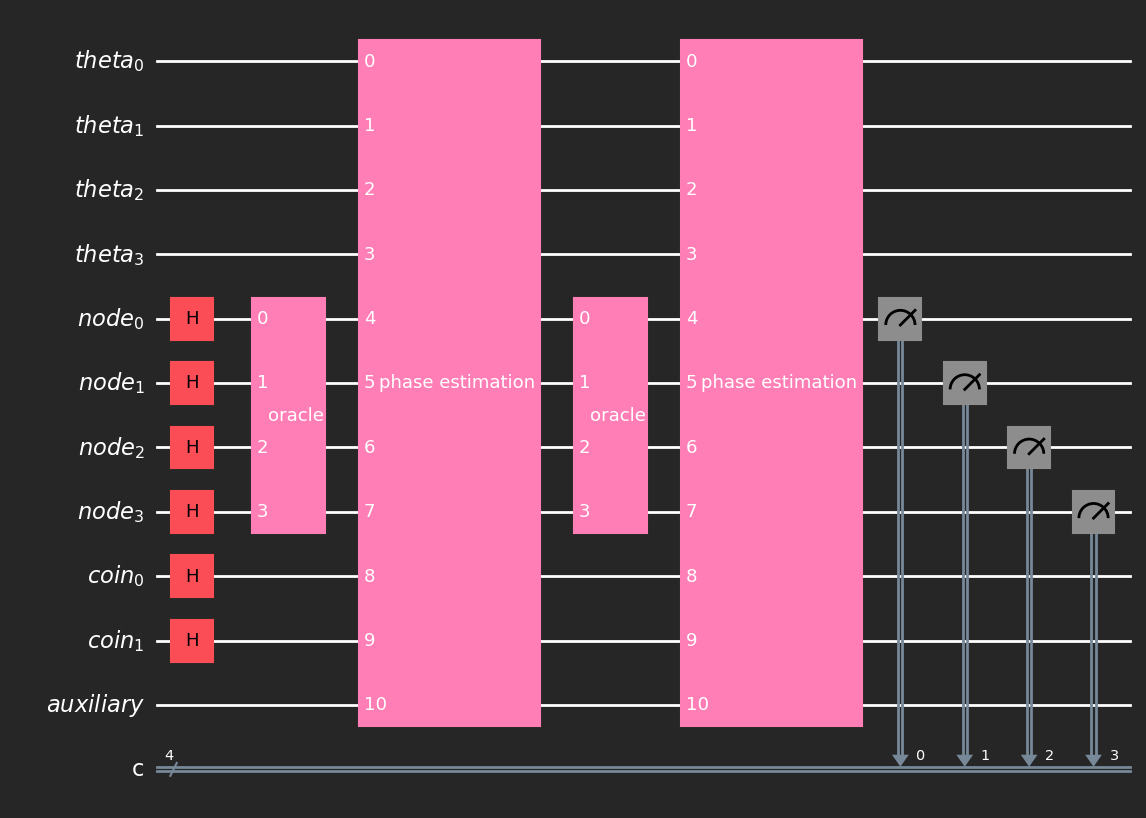

In [34]:
show_circuit(quantum_walk_circuit, 0)

# 08 Quantum Walk Algorithm (simple)

```python
def quantum_walk_simple(n, options=[]):
    # n = number of nodes in the waling graph
    # a simple version of the quantum walk algorithm that uses less quantum resources
    # assume coin qubit is always the most significant qubit
    # options = [starting_qubit, initialization, steps]
    # starting_qubit = index of the starting qubit, or 'random'
    # initialization = gate sequence to initialize the coin qubit, 'x', 'h', 's', or None
    # steps = number of walker steps
```

In [1]:
from Q_gen_search.quantum_walk_simple import quantum_walk_simple

In [2]:
quantum_walk_simple_circuit = quantum_walk_simple(4, ['random', ['h','s'], 2])

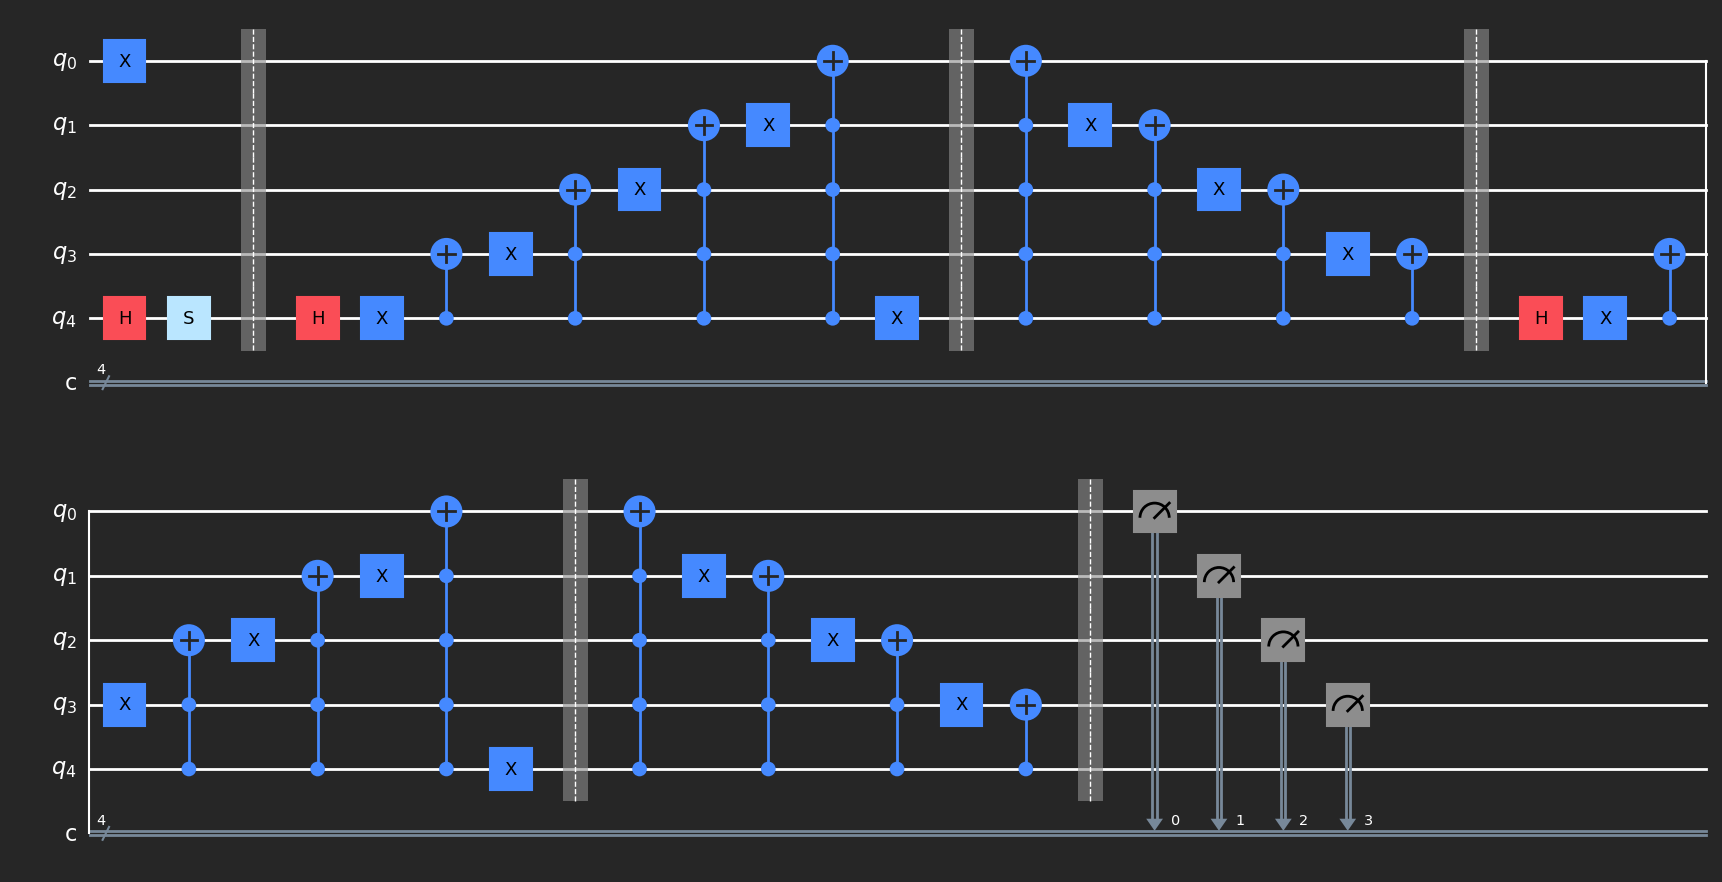

In [4]:
show_circuit(quantum_walk_simple_circuit, 0)

# 09 Quantum Key Distribution

```python
def quantum_key_distribution(n, options=[]):
    # options = [interception]
    # interception = 'interception', 'none', with/without eve's interception

def play_quantum_key_distribution(n, options=[]):
    # play a round of key distribution with simulation
    # options = [run_ideal_simulation]
    # run_ideal_simulation = run_ideal_simulation() from helper_functions.py
    # require "from helper_functions import run_ideal_simulation"
```

In [35]:
from Q_gen_communication.quantum_key_distribution import quantum_key_distribution

In [36]:
key_circuit = quantum_key_distribution(4, ['none'])

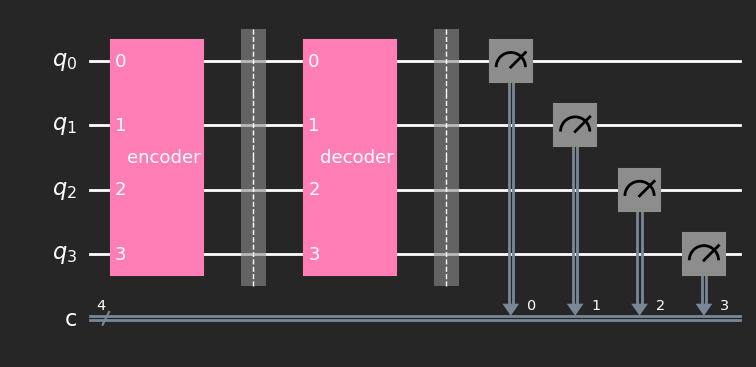

In [37]:
show_circuit(key_circuit, 0)

In [38]:
from Q_gen_communication.quantum_key_distribution import play_quantum_key_distribution
from helper_functions import run_ideal_simulation

In [39]:
play_key_circuit = play_quantum_key_distribution(8, [run_ideal_simulation])

alice bases =   11011010
alice message = 01011010
bob bases =   11000100
****eve bases (eve steals from bob)= 11000100
****eve message = 01010010
****eve key = ['0', '1', '0', '0']
bob message = 00000010
alice key = ['0', '1', '0', '0']
bob key =   ['0', '0', '0', '0']
test bit index = [3 3 1 3]
alice sample = ['0', '0', '1', '0']
bob sample   = ['0', '0', '0', '0']
Eve's interference was detected.


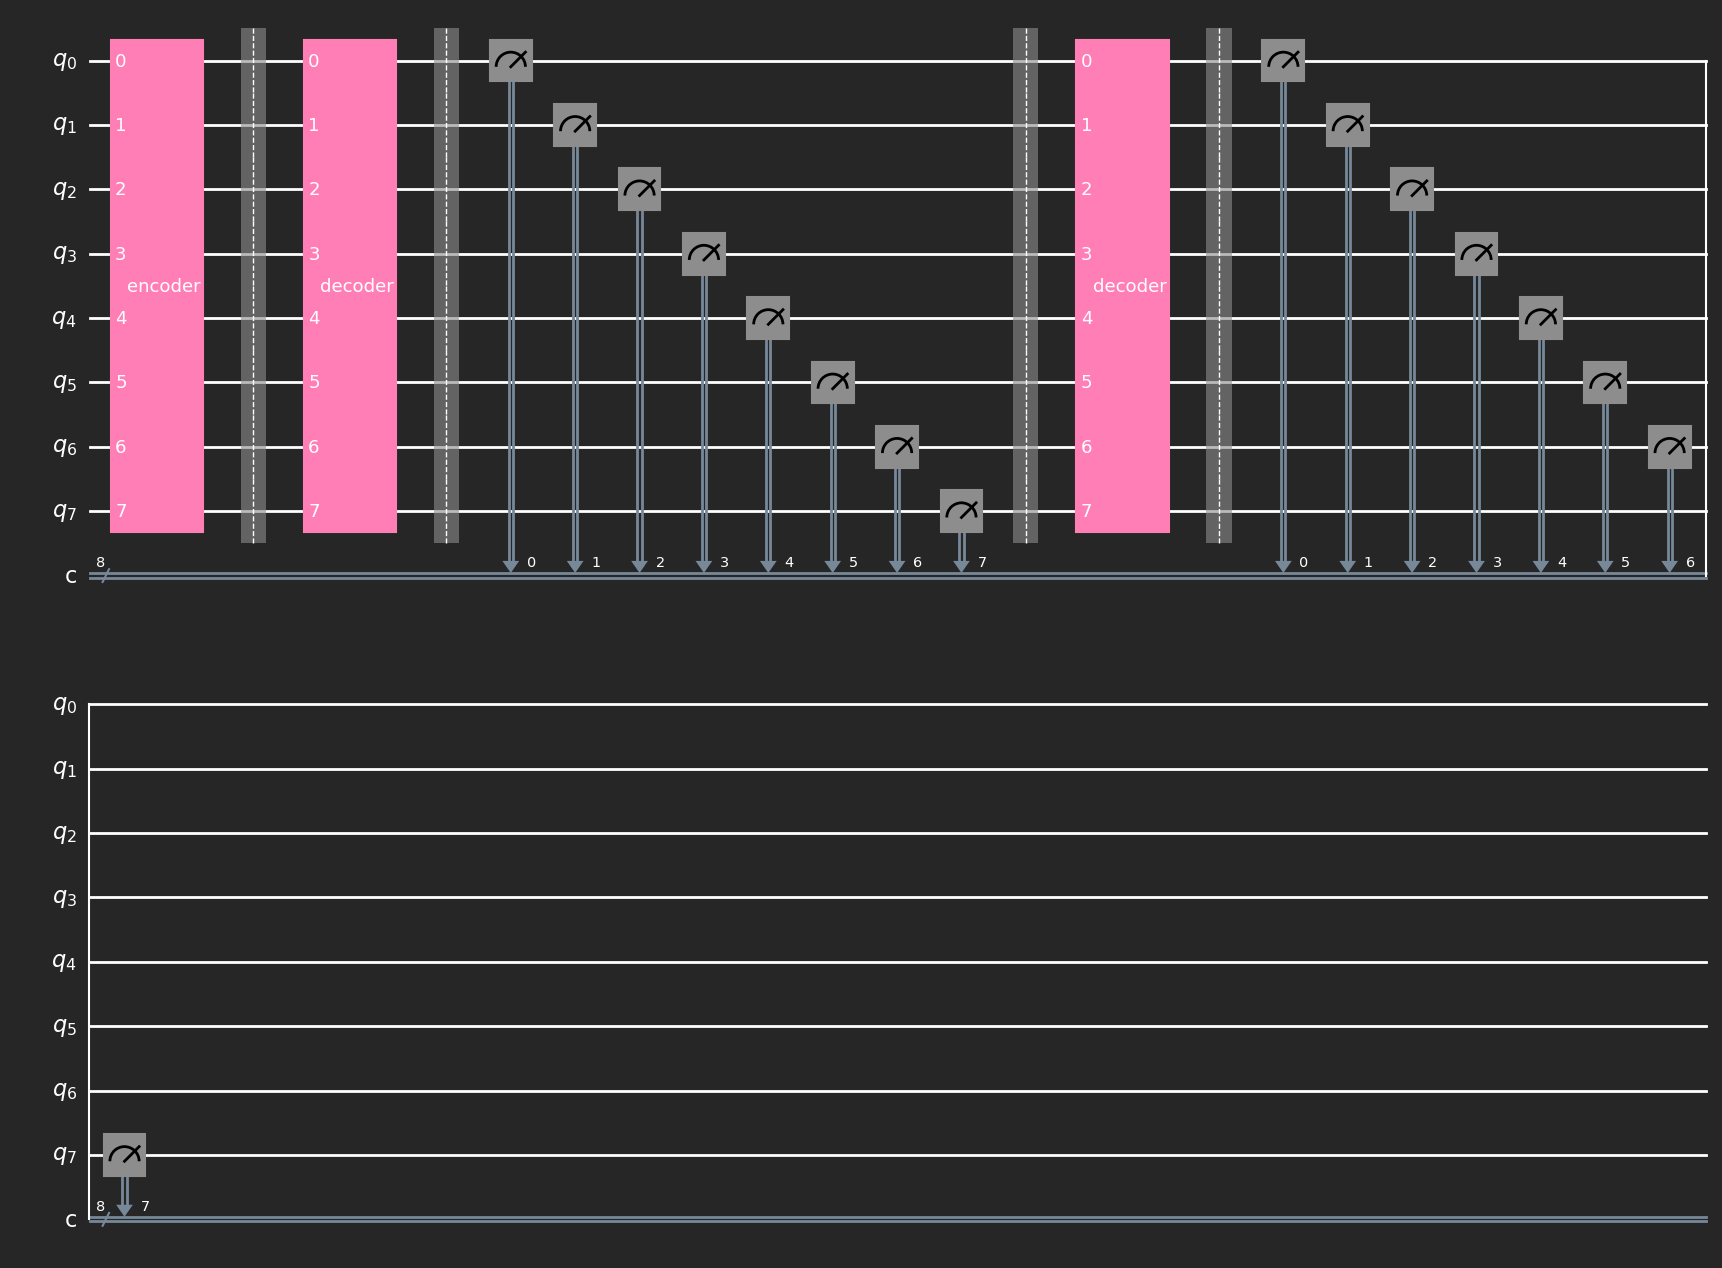

In [40]:
show_circuit(play_key_circuit, 0)

# 10 Superdense Coding

```python
def superdense_coding(n, options=[]):
    # options = [size]
    # size = 'all': encode all qubits. 'half': encode half qubits. or just provide a number, must <= n
```

In [41]:
from Q_gen_communication.superdense_coding import superdense_coding

In [42]:
superdense_circuit = superdense_coding(4, ['half'])

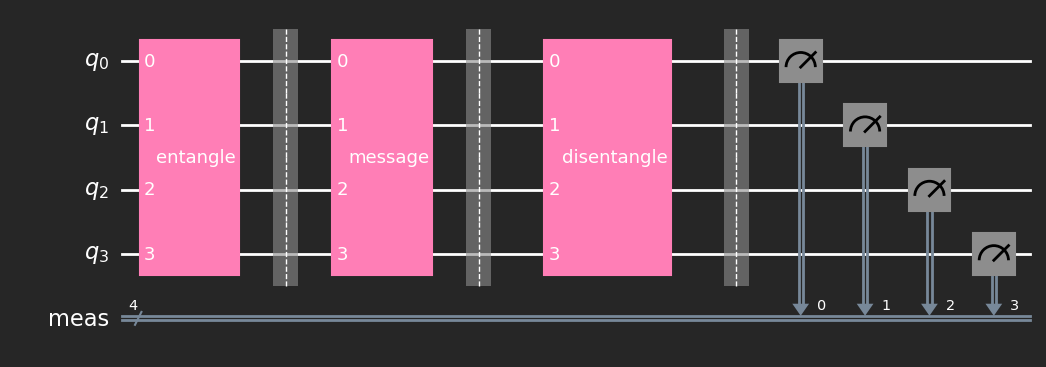

In [43]:
show_circuit(superdense_circuit, 0)

# 11 Quantum Teleportation

```python
def quantum_teleportation(n, options=[]):
    # options = [state]
    # state = specify the state to teleport (state=Statevector([0, 1])), or 'random'
```

In [44]:
from Q_gen_communication.quantum_teleportation import quantum_teleportation
from helper_functions import show_circuit, run_ideal_simulation, sim_result_analysis

In [45]:
teleportation_circuit = quantum_teleportation(2, ['random'])

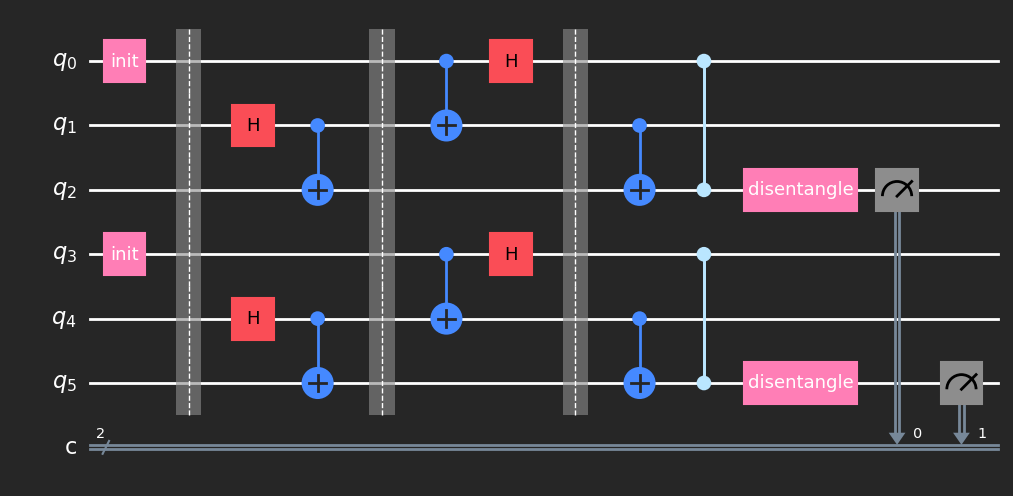

In [46]:
show_circuit(teleportation_circuit, 0)

---- START ----
simulator name = aer_simulator
max supported #qubits = 29
#qubits of circuit = 6
#clbits of circuit = 2
---- DONE ----
device = CPU
device time = 0.016434746
total time = 0.01712322235107422


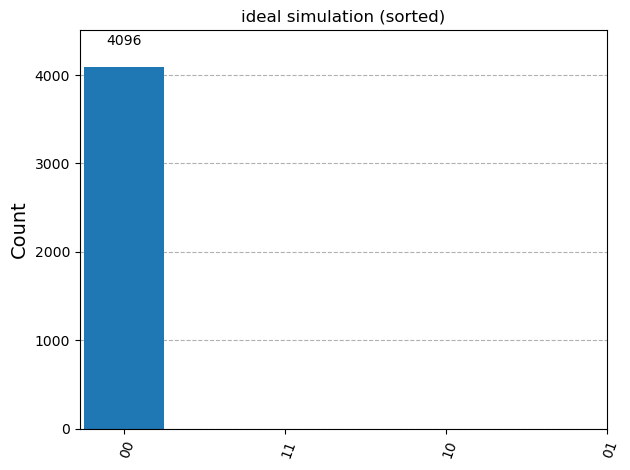

sorted counts:
{'00': 4096, '01': 0, '10': 0, '11': 0}
sorted probabilities (%):
{'00': 100.0, '01': 0.0, '10': 0.0, '11': 0.0}


In [47]:
teleportation_result = run_ideal_simulation(teleportation_circuit, 'CPU', 4096, 3, None, 'verbose')
sim_time, raw_counts, sorted_counts, sorted_probs = sim_result_analysis(teleportation_result, 'show_plot', 'show_counts', 'show_probs', 'verbose')

# 12 Quantum Approximate Optimization Algorithm 

```python
def qaoa(n, options=[]):
    # options = [graph, parameters]
    # graph = if 'cycle', use the default cycle graph. Else, supply custom networkx graph
    # parameters = if 'random', use random gamma/beta. Else, supply gamma and beta
```

In [48]:
from Q_gen_variational.qaoa import qaoa

In [49]:
qaoa_circuit = qaoa(4, ['cycle', 'random']) # max cut parameters = [pi/8.000, pi/2.666]

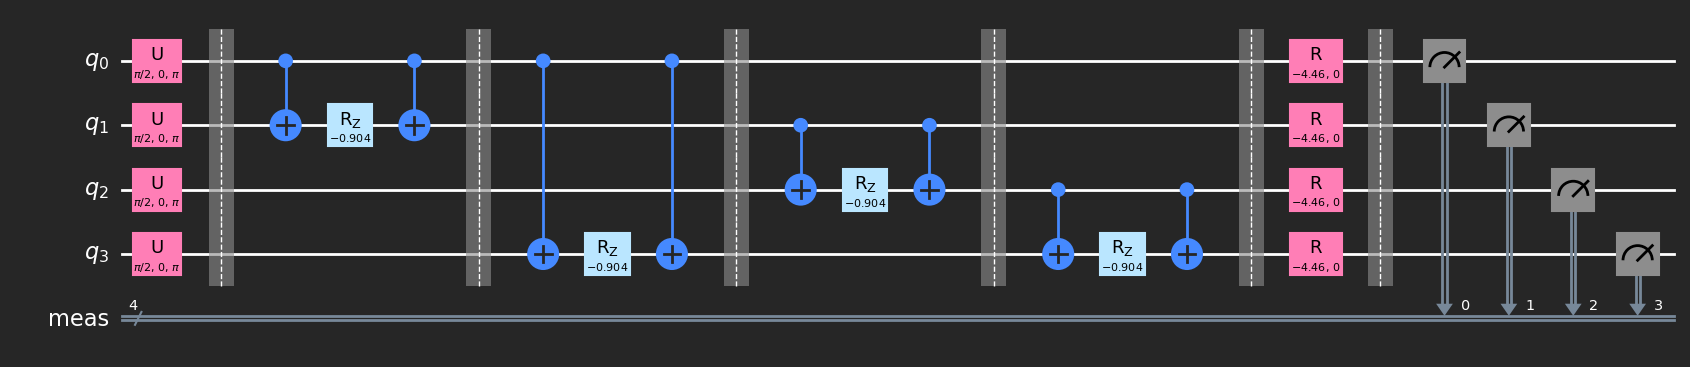

In [50]:
show_circuit(qaoa_circuit, 1)

# 13 Variational Quantum Eigensolver

```python
def vqe(n, options=[]):
    # options = [repeat, gates, entanglement]
    # repeat = how many times to repeat the variational form
    # gates = single qubit gates used in the variational form (['ry', 'rz'])
    # entanglement = CX between the single qubit gates (full, linear, reverse_linear, circular, sca)
    # parameters = a bind_dict for assigning the parameters to the gates, or 'random'
```

In [51]:
from Q_gen_variational.vqe import vqe

In [52]:
vqe_circuit = vqe(4, [1, ['ry', 'rz'], 'full','random']) # entanglement = 'full, linear, reverse_linear, circular, sca'

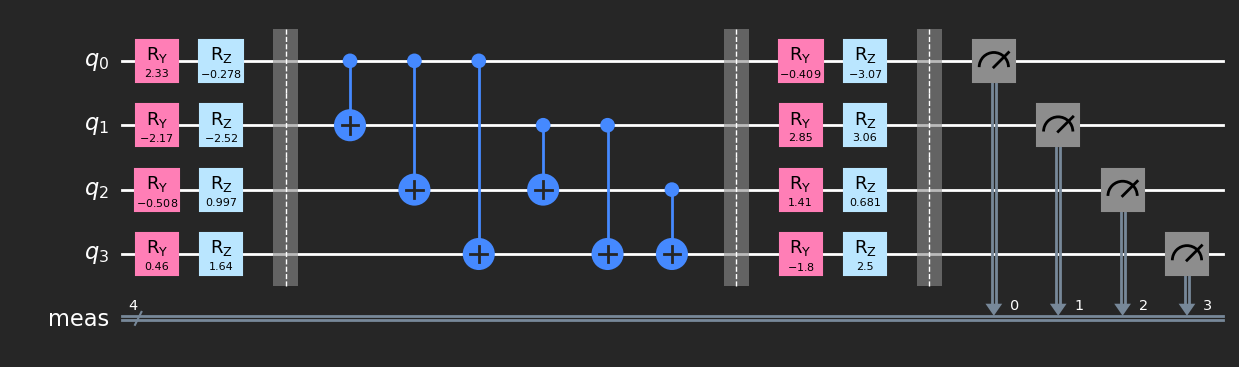

In [53]:
show_circuit(vqe_circuit, 0)

# 14 Variational Quantum Classifier

```python
def vqc(n, options=[]):
    # options = [repeat_f, repeat_v, parameters]
    # repeat_f = how many times to repeat the feature map
    # repeat_v = how many times to repeat the variational form
    # parameters = a bind_dict for assigning the parameters to the gates, or 'random'
```

In [54]:
from Q_gen_variational.vqc import vqc

In [55]:
vqc_circuit = vqc(4, [1, 1, 'random'])

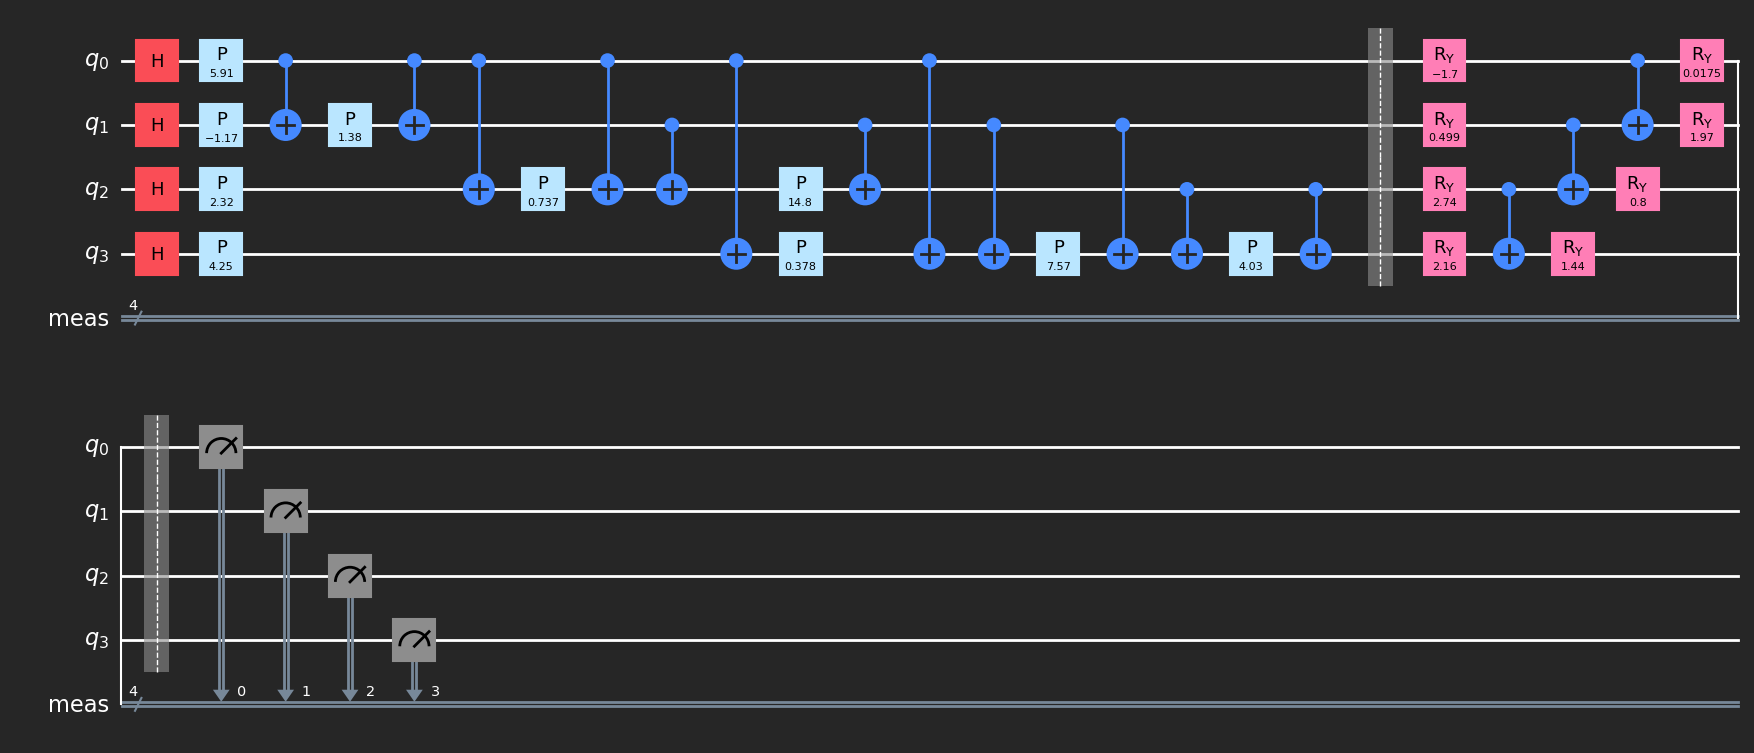

In [56]:
show_circuit(vqc_circuit, 1)